# 08 — How Many Beds Can Be Freed?

This notebook estimates bed-day savings from four independent levers, each grounded in
patterns documented in notebooks 03–07. All estimates use 2022+ data, annualized.

| Lever | Source notebook | Core insight |
|---|---|---|
| Hospital standardization | 04 | Same procedure, 2.7d variation across hospitals |
| Diagnostic outpatient shift | 05 | 20% of admissions are imaging-only |
| Long-stay reduction | 06 | 4.2% of patients use 23.7% of bed-days |
| ER-to-elective conversion | 02, 04 | ER admissions average 1.33d longer |

In [1]:
import sys; sys.path.insert(0, ".")
from shared import *
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

kidney = load_kidney()
recent = kidney[kidney["year"] >= 2022].copy()
n_years = recent["year"].nunique()

tags = pd.read_parquet(DATA_DIR / "hospital_tags.parquet")
recent = recent.merge(tags[["CNES", "broad_type"]], on="CNES", how="left")
recent["broad_type"] = recent["broad_type"].fillna("unknown")

total_bed_days = recent["DIAS_PERM"].sum()
total_bed_days_annual = total_bed_days / n_years
print(f"Period: {int(recent['year'].min())}–{int(recent['year'].max())} ({n_years} years)")
print(f"Total admissions (2022+): {len(recent):,}")
print(f"Total bed-days: {total_bed_days:,.0f}")
print(f"Average annual bed-days: {total_bed_days_annual:,.0f}")

print(f"\nBed-days by facility type:")
for bt, bd in recent.groupby("broad_type")["DIAS_PERM"].sum().sort_values(ascending=False).items():
    pct = bd / total_bed_days * 100
    print(f"  {bt}: {bd:,.0f} ({pct:.1f}%)")

Period: 2022–2025 (4 years)
Total admissions (2022+): 108,697
Total bed-days: 245,813
Average annual bed-days: 61,453

Bed-days by facility type:
  hospital_geral: 234,418 (95.4%)
  hospital_dia: 7,342 (3.0%)
  hospital_especializado: 2,924 (1.2%)
  pronto_socorro: 975 (0.4%)
  pronto_atendimento: 64 (0.0%)
  upa: 51 (0.0%)
  unknown: 37 (0.0%)
  other: 2 (0.0%)


---
## Scenario 1: Hospital Standardization

**Insight from Notebook 04:** The same procedure yields wildly different LOS depending
on the hospital. The hospital effect (2.66d) is 2.1× larger than the procedure effect (1.24d).

**Method:** For each of the top-10 procedures by volume, identify hospitals in the
bottom quartile (worst 25%) of LOS. Calculate how many bed-days would be saved if those
hospitals improved to the system median for that procedure. This is *procedure-controlled* —
we're not penalizing hospitals for doing complex procedures; we're comparing like-with-like.

**Assumption:** Bottom-quartile hospitals can reach the median. This is conservative —
the median is already achievable by 50% of hospitals.

In [2]:
cnes_type_map = tags.set_index("CNES")["broad_type"].to_dict()

# Focus on Hospital Geral only — day hospitals and UPAs have different bed usage
geral_recent = recent[recent["broad_type"] == "hospital_geral"]
savings_hosp = 0
details_hosp = []

for proc in geral_recent["PROC_REA"].value_counts().head(10).index:
    proc_data = geral_recent[geral_recent["PROC_REA"] == proc]
    hosp = proc_data.groupby("CNES").agg(
        n=("DIAG_PRINC", "count"),
        avg_los=("DIAS_PERM", "mean"),
    ).query("n >= 10")
    if len(hosp) < 4:
        continue

    median_los = hosp["avg_los"].median()
    q75 = hosp["avg_los"].quantile(0.75)
    bottom = hosp[hosp["avg_los"] > q75]

    proc_label = PROC_NAMES.get(proc, proc)
    for cnes, r in bottom.iterrows():
        excess = (r["avg_los"] - median_los) * r["n"]
        if excess > 0:
            savings_hosp += excess
            details_hosp.append({
                "proc": proc, "proc_label": proc_label,
                "cnes": cnes, "n": r["n"],
                "avg_los": r["avg_los"], "median_los": median_los,
                "excess_bd": excess,
                "facility_type": cnes_type_map.get(cnes, "unknown"),
            })

savings_hosp_annual = savings_hosp / n_years
details_df = pd.DataFrame(details_hosp).sort_values("excess_bd", ascending=False)

print(f"Scenario 1 — Hospital standardization (Hospital Geral only): {savings_hosp_annual:,.0f} bed-days/year saved")
print(f"  Hospitals contributing excess: {len(details_df)}")
print(f"  Top contributors:")
for _, r in details_df.head(8).iterrows():
    print(f"    CNES {r['cnes']} ({r['facility_type']}) | {r['proc_label'][:30]:<30} | n={r['n']:.0f} | "
          f"LOS {r['avg_los']:.1f}d (median {r['median_los']:.1f}d) | excess: {r['excess_bd']:.0f} bd")

Scenario 1 — Hospital standardization (Hospital Geral only): 8,479 bed-days/year saved
  Hospitals contributing excess: 194
  Top contributors:
    CNES 2755130 (hospital_geral) | Ureteroscopy (modern)          | n=2842 | LOS 2.7d (median 1.5d) | excess: 3456 bd
    CNES 9465464 (hospital_geral) | Ureteroscopy (modern)          | n=1390 | LOS 3.0d (median 1.5d) | excess: 2050 bd
    CNES 2081695 (hospital_geral) | Ureteroscopy (modern)          | n=1137 | LOS 3.0d (median 1.5d) | excess: 1703 bd
    CNES 2688689 (hospital_geral) | Ureteroscopy (modern)          | n=354 | LOS 5.3d (median 1.5d) | excess: 1360 bd
    CNES 2081695 (hospital_geral) | Open Ureterolithotomy          | n=996 | LOS 4.3d (median 2.9d) | excess: 1352 bd
    CNES 6095666 (hospital_geral) | Ureteroscopy (modern)          | n=1164 | LOS 2.6d (median 1.5d) | excess: 1228 bd
    CNES 2688689 (hospital_geral) | Open Ureterolithotomy          | n=296 | LOS 6.4d (median 2.9d) | excess: 1022 bd
    CNES 2080346 (hospital

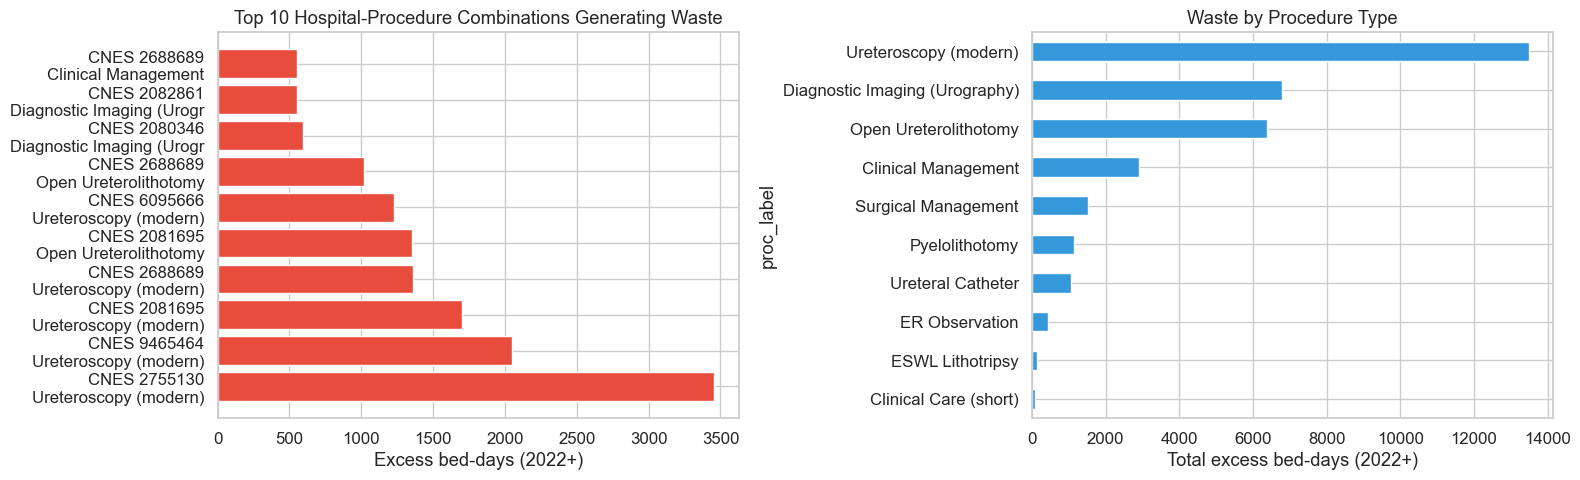

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_details = details_df.head(10).copy()
top_details["label"] = top_details.apply(
    lambda r: f"CNES {r['cnes']}\n{r['proc_label'][:25]}", axis=1)
axes[0].barh(top_details["label"], top_details["excess_bd"], color="#e74c3c")
axes[0].set_xlabel("Excess bed-days (2022+)")
axes[0].set_title("Top 10 Hospital-Procedure Combinations Generating Waste")

by_proc = details_df.groupby("proc_label")["excess_bd"].sum().sort_values(ascending=True)
by_proc.plot.barh(ax=axes[1], color="#3498db")
axes[1].set_xlabel("Total excess bed-days (2022+)")
axes[1].set_title("Waste by Procedure Type")

plt.tight_layout()
plt.savefig(PLOT_DIR / "08_hosp_standardization_detail.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Scenario 2: Diagnostic Outpatient Shift

**Insight from Notebook 05:** 20.1% of all kidney stone admissions are for diagnostic
imaging only (urography or CT). These patients are admitted through the ER (94%), kept
for an average of 2.7 days, and discharged without any treatment. The imaging itself
takes hours, not days.

**Method:** Take the total bed-days consumed by diagnostic admissions in 2022+ and
assume 50% could be shifted to outpatient imaging. This is conservative — in well-run
systems, nearly all routine imaging is outpatient.

**Why only 50%?** Some patients have genuine acute presentations requiring observation
(e.g., severe pain, suspected obstruction). We don't assume all can be redirected.

In [4]:
diag = recent[recent["proc_category"] == "DIAGNOSTIC"]
non_diag = recent[recent["proc_category"] != "DIAGNOSTIC"]
diag_bed_days = diag["DIAS_PERM"].sum()
shift_pct = 0.5
savings_diag = diag_bed_days * shift_pct
savings_diag_annual = savings_diag / n_years

print(f"Diagnostic admissions (2022+): {len(diag):,} ({len(diag)/len(recent)*100:.1f}%)")
print(f"Diagnostic bed-days: {diag_bed_days:,.0f} ({diag_bed_days/total_bed_days*100:.1f}% of total)")
print(f"Diagnostic cost: R$ {diag['VAL_TOT'].sum():,.0f}")
print(f"ER rate: {diag['is_emergency'].mean()*100:.1f}%")
print(f"Avg LOS: {diag['DIAS_PERM'].mean():.1f}d")
print(f"\nScenario 2 — Diagnostic shift (50%): {savings_diag_annual:,.0f} bed-days/year saved")

Diagnostic admissions (2022+): 18,078 (16.6%)
Diagnostic bed-days: 48,931 (19.9% of total)
Diagnostic cost: R$ 7,108,214
ER rate: 94.2%
Avg LOS: 2.7d

Scenario 2 — Diagnostic shift (50%): 6,116 bed-days/year saved


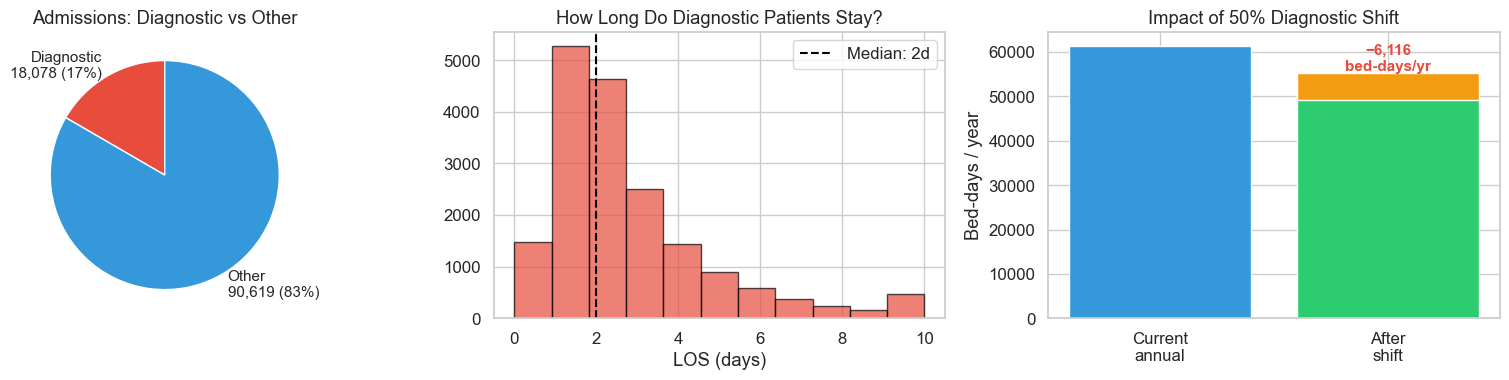

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sizes = [len(diag), len(non_diag)]
labels = [f"Diagnostic\n{len(diag):,} ({len(diag)/len(recent)*100:.0f}%)",
          f"Other\n{len(non_diag):,} ({len(non_diag)/len(recent)*100:.0f}%)"]
axes[0].pie(sizes, labels=labels, colors=["#e74c3c", "#3498db"],
            autopct="", startangle=90, textprops={"fontsize": 11})
axes[0].set_title("Admissions: Diagnostic vs Other")

diag["DIAS_PERM"].clip(upper=10).hist(bins=11, ax=axes[1], edgecolor="black", color="#e74c3c", alpha=0.7)
axes[1].axvline(diag["DIAS_PERM"].median(), color="black", linestyle="--",
                label=f"Median: {diag['DIAS_PERM'].median():.0f}d")
axes[1].set_xlabel("LOS (days)")
axes[1].set_title("How Long Do Diagnostic Patients Stay?")
axes[1].legend()

bed_days_diag = diag_bed_days
bed_days_other = total_bed_days - bed_days_diag
shifted = bed_days_diag * shift_pct / n_years
remaining = bed_days_diag * (1 - shift_pct) / n_years
other_annual = bed_days_other / n_years
bars = axes[2].bar(["Current\nannual", "After\nshift"],
                   [total_bed_days_annual, other_annual + remaining],
                   color=["#3498db", "#2ecc71"])
axes[2].bar(["After\nshift"], [remaining], bottom=[other_annual], color="#f39c12", label="Remaining diagnostic")
diff = total_bed_days_annual - (other_annual + remaining)
axes[2].annotate(f"−{diff:,.0f}\nbed-days/yr", xy=(1, other_annual + remaining + 500),
                 fontsize=11, ha="center", color="#e74c3c", fontweight="bold")
axes[2].set_ylabel("Bed-days / year")
axes[2].set_title("Impact of 50% Diagnostic Shift")

plt.tight_layout()
plt.savefig(PLOT_DIR / "08_diagnostic_shift_detail.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Scenario 3: Long-Stay Reduction

**Insight from Notebook 06:** 4.2% of patients stay >7 days, but they consume 23.7%
of all bed-days and 50.1% of all deaths. The excess days above 7 represent a mix of
complications, social admissions, and inefficient discharge planning.

**Method:** Calculate total excess bed-days above the 7-day threshold for all long-stay
patients. Assume 50% of this excess can be eliminated through care coordination,
discharge planning, and complication prevention.

**Why 50%?** Some long stays are medically necessary (complex cases, post-surgical
complications). We target the avoidable portion.

In [6]:
long_stay = recent[recent["DIAS_PERM"] > 7]
normal = recent[recent["DIAS_PERM"] <= 7]
excess_bd_longstay = (long_stay["DIAS_PERM"] - 7).sum()
reduction_pct = 0.5
savings_longstay = excess_bd_longstay * reduction_pct
savings_longstay_annual = savings_longstay / n_years

print(f"Long-stay patients (>7d): {len(long_stay):,} ({len(long_stay)/len(recent)*100:.1f}%)")
print(f"Bed-days consumed: {long_stay['DIAS_PERM'].sum():,.0f} ({long_stay['DIAS_PERM'].sum()/total_bed_days*100:.1f}%)")
print(f"Deaths: {long_stay['MORTE'].sum():.0f} ({long_stay['MORTE'].sum()/max(recent['MORTE'].sum(),1)*100:.1f}%)")
print(f"Excess bed-days above 7d: {excess_bd_longstay:,.0f}")
print(f"Avg excess per patient: {excess_bd_longstay/len(long_stay):.1f}d")
print(f"\nScenario 3 — Long-stay reduction (50%): {savings_longstay_annual:,.0f} bed-days/year saved")

Long-stay patients (>7d): 4,531 (4.2%)
Bed-days consumed: 58,254 (23.7%)
Deaths: 176 (50.1%)
Excess bed-days above 7d: 26,537
Avg excess per patient: 5.9d

Scenario 3 — Long-stay reduction (50%): 3,317 bed-days/year saved


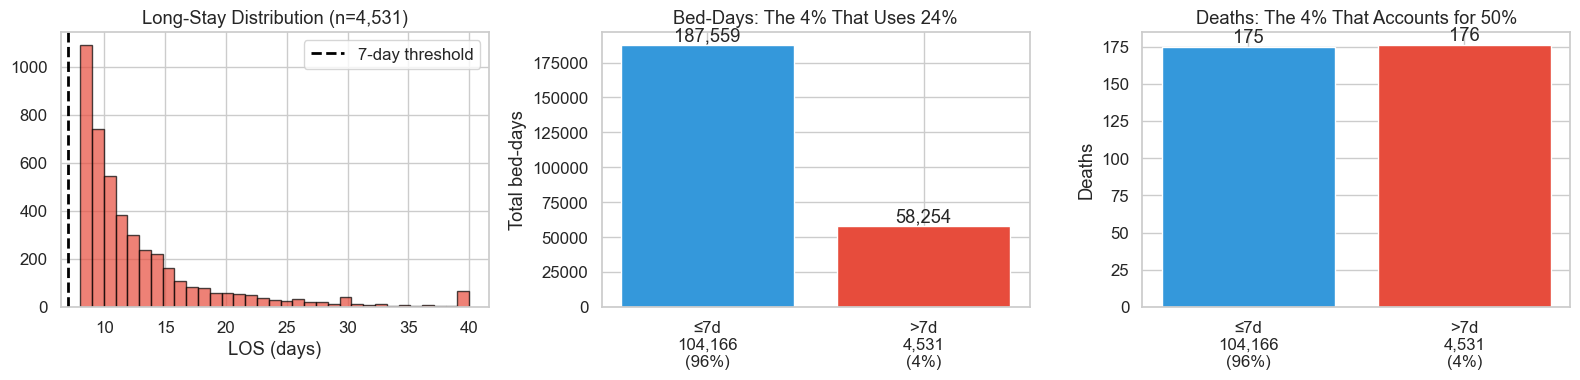

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

long_stay["DIAS_PERM"].clip(upper=40).hist(bins=33, ax=axes[0], edgecolor="black", color="#e74c3c", alpha=0.7)
axes[0].axvline(7, color="black", linestyle="--", linewidth=2, label="7-day threshold")
axes[0].set_xlabel("LOS (days)")
axes[0].set_title(f"Long-Stay Distribution (n={len(long_stay):,})")
axes[0].legend()

labels_ls = [f"≤7d\n{len(normal):,}\n({len(normal)/len(recent)*100:.0f}%)",
             f">7d\n{len(long_stay):,}\n({len(long_stay)/len(recent)*100:.0f}%)"]
bd_vals = [normal["DIAS_PERM"].sum(), long_stay["DIAS_PERM"].sum()]
bars = axes[1].bar(labels_ls, bd_vals, color=["#3498db", "#e74c3c"])
axes[1].bar_label(bars, fmt=lambda x: f"{x:,.0f}")
axes[1].set_ylabel("Total bed-days")
axes[1].set_title("Bed-Days: The 4% That Uses 24%")

death_vals = [normal["MORTE"].sum(), long_stay["MORTE"].sum()]
bars2 = axes[2].bar(labels_ls, death_vals, color=["#3498db", "#e74c3c"])
axes[2].bar_label(bars2, fmt=lambda x: f"{x:.0f}")
axes[2].set_ylabel("Deaths")
axes[2].set_title("Deaths: The 4% That Accounts for 50%")

plt.tight_layout()
plt.savefig(PLOT_DIR / "08_long_stay_detail.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Scenario 4: ER-to-Elective Conversion

**Insight from Notebooks 02 & 04:** 52% of kidney stone admissions arrive through the ER.
ER admissions have 1.33 days longer LOS on average (2.90d vs 1.57d). This isn't just
acuity — many ER patients have conditions that could be managed through elective scheduling
if upstream referral pathways existed.

**Method:** Take 30% of ER patients (the assumed convertible fraction) and apply the
LOS difference between ER and elective admissions.

**Why only 30%?** Many ER arrivals are genuinely acute (renal colic, obstruction).
We target the subset that could be caught earlier — patients who present multiple times,
patients with known stones awaiting surgery, and patients from cities without local
surgical capability who default to ER as the entry point.

In [8]:
er = recent[recent["is_emergency"] == 1]
elective = recent[recent["is_emergency"] == 0]
er_los = er["DIAS_PERM"].mean()
elective_los = elective["DIAS_PERM"].mean()
los_diff = er_los - elective_los

convert_pct = 0.3
savings_er = len(er) * convert_pct * los_diff
savings_er_annual = savings_er / n_years

print(f"ER admissions (2022+): {len(er):,} ({len(er)/len(recent)*100:.1f}%)")
print(f"Elective admissions: {len(elective):,} ({len(elective)/len(recent)*100:.1f}%)")
print(f"ER avg LOS: {er_los:.2f}d | Elective avg LOS: {elective_los:.2f}d | Difference: {los_diff:.2f}d")
print(f"Convertible patients (30%): {len(er)*convert_pct:,.0f}")
print(f"\nScenario 4 — ER-to-elective (30%): {savings_er_annual:,.0f} bed-days/year saved")

ER admissions (2022+): 56,359 (51.8%)
Elective admissions: 52,338 (48.2%)
ER avg LOS: 2.90d | Elective avg LOS: 1.57d | Difference: 1.33d
Convertible patients (30%): 16,908

Scenario 4 — ER-to-elective (30%): 5,606 bed-days/year saved


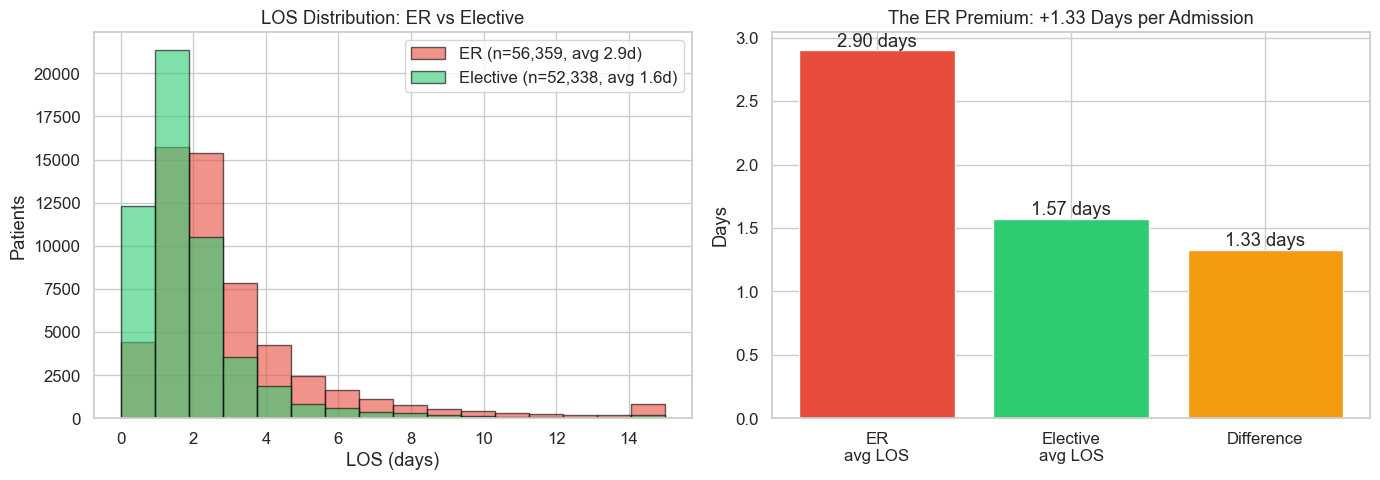

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

er["DIAS_PERM"].clip(upper=15).hist(bins=16, ax=axes[0], alpha=0.6, color="#e74c3c",
                                      edgecolor="black", label=f"ER (n={len(er):,}, avg {er_los:.1f}d)")
elective["DIAS_PERM"].clip(upper=15).hist(bins=16, ax=axes[0], alpha=0.6, color="#2ecc71",
                                            edgecolor="black", label=f"Elective (n={len(elective):,}, avg {elective_los:.1f}d)")
axes[0].set_xlabel("LOS (days)")
axes[0].set_ylabel("Patients")
axes[0].set_title("LOS Distribution: ER vs Elective")
axes[0].legend()

cats = ["ER\navg LOS", "Elective\navg LOS", "Difference"]
vals = [er_los, elective_los, los_diff]
colors = ["#e74c3c", "#2ecc71", "#f39c12"]
bars = axes[1].bar(cats, vals, color=colors)
axes[1].bar_label(bars, fmt="%.2f days")
axes[1].set_ylabel("Days")
axes[1].set_title(f"The ER Premium: +{los_diff:.2f} Days per Admission")

plt.tight_layout()
plt.savefig(PLOT_DIR / "08_er_vs_elective.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Combined Estimate

These four levers are largely independent — a patient could benefit from hospital
standardization AND ER-to-elective conversion, but the estimates don't double-count
because they target different mechanisms. Some overlap exists (e.g., diagnostic
patients who are also ER), so the combined total should be read as an upper bound.

In [10]:
scenarios = {
    "Hospital standardization": savings_hosp_annual,
    "Diagnostic outpatient shift": savings_diag_annual,
    "Long-stay reduction": savings_longstay_annual,
    "ER-to-elective conversion": savings_er_annual,
}

total_savings = sum(scenarios.values())
bed_equivalents = total_savings / 365

print(f"\n{'='*60}")
print(f"  COMBINED BED SAVINGS ESTIMATE")
print(f"{'='*60}\n")
for name, val in scenarios.items():
    print(f"  {name:<35} {val:>8,.0f} bed-days/yr ({val/365:.0f} beds)")
print(f"\n  {'TOTAL':<35} {total_savings:>8,.0f} bed-days/yr ({bed_equivalents:.0f} beds)")
print(f"\n  Current annual bed-days: {total_bed_days_annual:,.0f}")
print(f"  Potential reduction: {total_savings/total_bed_days_annual*100:.1f}%")


  COMBINED BED SAVINGS ESTIMATE

  Hospital standardization               8,479 bed-days/yr (23 beds)
  Diagnostic outpatient shift            6,116 bed-days/yr (17 beds)
  Long-stay reduction                    3,317 bed-days/yr (9 beds)
  ER-to-elective conversion              5,606 bed-days/yr (15 beds)

  TOTAL                                 23,519 bed-days/yr (64 beds)

  Current annual bed-days: 61,453
  Potential reduction: 38.3%


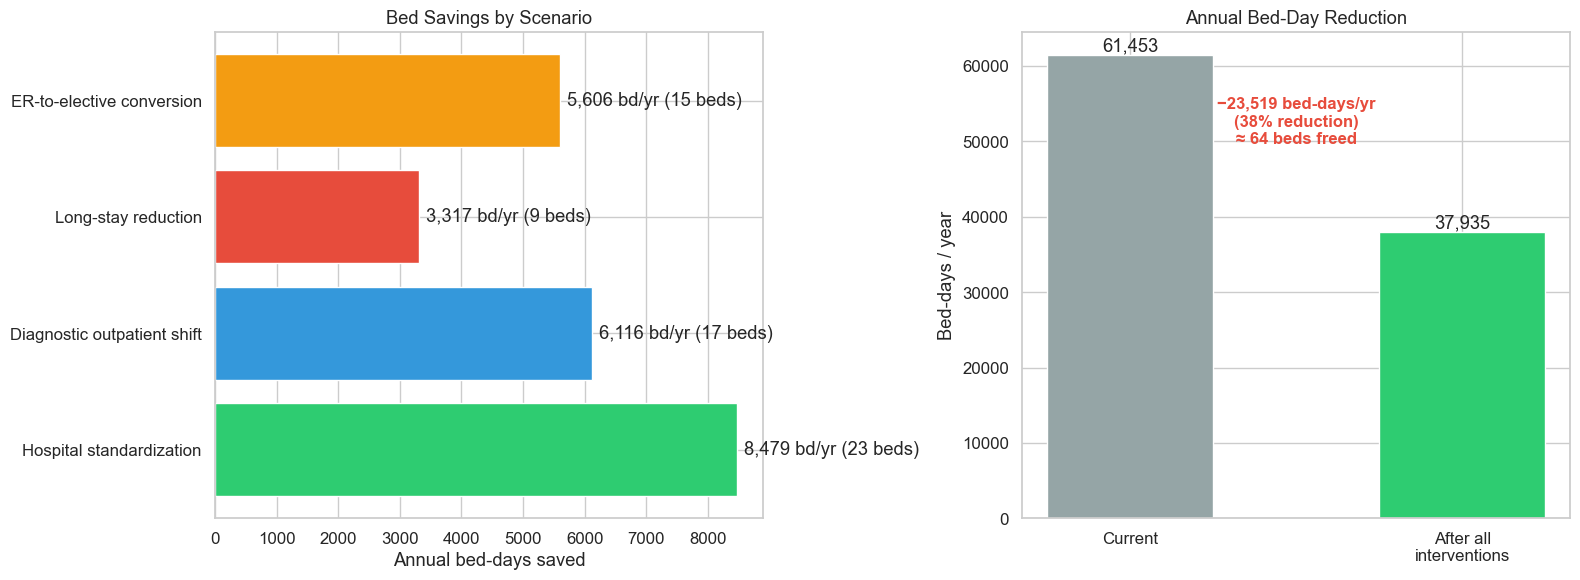

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names = list(scenarios.keys())
vals = list(scenarios.values())
colors = ["#2ecc71", "#3498db", "#e74c3c", "#f39c12"]
bars = axes[0].barh(names, vals, color=colors)
axes[0].bar_label(bars, fmt=lambda x: f"{x:,.0f} bd/yr ({x/365:.0f} beds)", padding=5)
axes[0].set_xlabel("Annual bed-days saved")
axes[0].set_title("Bed Savings by Scenario")

current = total_bed_days_annual
after = current - total_savings
bars2 = axes[1].bar(["Current", "After all\ninterventions"],
                    [current, after], color=["#95a5a6", "#2ecc71"], width=0.5)
axes[1].bar_label(bars2, fmt=lambda x: f"{x:,.0f}")
axes[1].annotate(f"−{total_savings:,.0f} bed-days/yr\n({total_savings/current*100:.0f}% reduction)\n≈ {bed_equivalents:.0f} beds freed",
                 xy=(0.5, (current + after) / 2), fontsize=12, ha="center",
                 color="#e74c3c", fontweight="bold")
axes[1].set_ylabel("Bed-days / year")
axes[1].set_title("Annual Bed-Day Reduction")

plt.tight_layout()
plt.savefig(PLOT_DIR / "08_bed_savings.png", dpi=150, bbox_inches="tight")
plt.show()

### Sensitivity & Limitations

| Parameter | Value used | Optimistic | Pessimistic |
|---|---|---|---|
| Hospital target | Median | P25 (ambitious) | P60 (easy wins) |
| Diagnostic shift % | 50% | 80% | 20% |
| Long-stay reduction % | 50% | 70% | 30% |
| ER conversion % | 30% | 50% | 15% |

**Key limitation:** These scenarios assume interventions are implemented. The numbers
represent *addressable* waste, not guaranteed savings. Implementation requires changes
to hospital protocols, referral pathways, and outpatient infrastructure.

## Save metrics

In [12]:
metrics = {
    "scenarios": {k: {"bed_days_per_year": round(v, 0), "beds": round(v/365, 0)} for k, v in scenarios.items()},
    "total_savings_bed_days_per_year": round(total_savings, 0),
    "total_beds": round(bed_equivalents, 0),
    "total_pct_reduction": round(total_savings / total_bed_days_annual * 100, 1),
}
with open(METRICS_DIR / "bed_savings.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved bed_savings.json")

Saved bed_savings.json
